#### 🧩 Step 1: Initialize Weights and Biases

In [22]:
import numpy as np
np.random.seed(0)
X = np.array([[0.5, -0.2]])  # one sample with 2 features
y = np.array([[1, 0]])       # true label (class 0)

W1 = np.random.randn(2, 3)   # weights: input → hidden
b1 = np.zeros((3,))          # bias for hidden layer

W2 = np.random.randn(3, 2)   # weights: hidden → output
b2 = np.zeros((2,))          # bias for output layer


#### 🧠 Step 2: Forward Pass

In [23]:
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

# Hidden layer
z1 = X @ W1 + b1
a1 = relu(z1)

# Output layer
z2 = a1 @ W2 + b2
yhat = softmax(z2)


In [24]:
print("z1 =", z1)
print("a1 =", a1)
print("z2 =", z2)
print("yhat =", yhat)


z1 = [[ 0.43384753 -0.17343299  0.68482457]]
a1 = [[0.43384753 0.         0.68482457]]
z2 = [[0.51083809 0.93025627]]
yhat = [[0.39665598 0.60334402]]


#### 📉 Step 3: Loss Function (Cross-Entropy)

In [25]:
loss = -np.sum(y * np.log(yhat))
print("Loss =", loss)


Loss = 0.9246859169927294


#### 🔁 Step 4: Backward Propagation (Manual Gradients)

In [26]:
# Output layer gradients
dz2 = yhat - y                  # shape (1,2)
dW2 = a1.T @ dz2                # shape (3,2)
db2 = dz2                       # shape (1,2)

# Hidden layer gradients
da1 = dz2 @ W2.T                # shape (1,3)
dz1 = da1 * (z1 > 0)            # ReLU derivative
dW1 = X.T @ dz1                 # shape (2,3)
db1 = dz1                       # shape (1,3)


#### 🔧 Step 5: Weight Update

In [27]:
lr = 0.1
W1 -= lr * dW1
b1 -= lr * db1.squeeze()
W2 -= lr * dW2
b2 -= lr * db2.squeeze()


#### if you want to do that for certain number of time

In [28]:
import numpy as np

np.random.seed(0)
X = np.array([[0.5, -0.2]])  # one sample with 2 features
y = np.array([[1, 0]])       # true label (class 0)

# Initialize weights and biases
W1 = np.random.randn(2, 3)
b1 = np.zeros((3,))
W2 = np.random.randn(3, 2)
b2 = np.zeros((2,))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

lr = 0.1
losses = []

for epoch in range(50):  # run for 50 epochs
    # Forward pass
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    yhat = softmax(z2)

    # Loss
    loss = -np.sum(y * np.log(yhat))
    losses.append(loss)

    # Backward pass
    dz2 = yhat - y
    dW2 = a1.T @ dz2
    db2 = dz2

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)
    dW1 = X.T @ dz1
    db1 = dz1

    # Update weights
    W1 -= lr * dW1
    b1 -= lr * db1.squeeze()
    W2 -= lr * dW2
    b2 -= lr * db2.squeeze()

    print(f"Epoch {epoch+1}: Loss = {loss:.4f}")


Epoch 1: Loss = 0.9247
Epoch 2: Loss = 0.6908
Epoch 3: Loss = 0.5346
Epoch 4: Loss = 0.4265
Epoch 5: Loss = 0.3490
Epoch 6: Loss = 0.2918
Epoch 7: Loss = 0.2484
Epoch 8: Loss = 0.2146
Epoch 9: Loss = 0.1878
Epoch 10: Loss = 0.1661
Epoch 11: Loss = 0.1483
Epoch 12: Loss = 0.1335
Epoch 13: Loss = 0.1210
Epoch 14: Loss = 0.1104
Epoch 15: Loss = 0.1013
Epoch 16: Loss = 0.0934
Epoch 17: Loss = 0.0865
Epoch 18: Loss = 0.0805
Epoch 19: Loss = 0.0751
Epoch 20: Loss = 0.0703
Epoch 21: Loss = 0.0661
Epoch 22: Loss = 0.0622
Epoch 23: Loss = 0.0588
Epoch 24: Loss = 0.0556
Epoch 25: Loss = 0.0528
Epoch 26: Loss = 0.0501
Epoch 27: Loss = 0.0478
Epoch 28: Loss = 0.0456
Epoch 29: Loss = 0.0435
Epoch 30: Loss = 0.0417
Epoch 31: Loss = 0.0399
Epoch 32: Loss = 0.0383
Epoch 33: Loss = 0.0368
Epoch 34: Loss = 0.0354
Epoch 35: Loss = 0.0341
Epoch 36: Loss = 0.0329
Epoch 37: Loss = 0.0318
Epoch 38: Loss = 0.0308
Epoch 39: Loss = 0.0299
Epoch 40: Loss = 0.0290
Epoch 41: Loss = 0.0282
Epoch 42: Loss = 0.0274
E

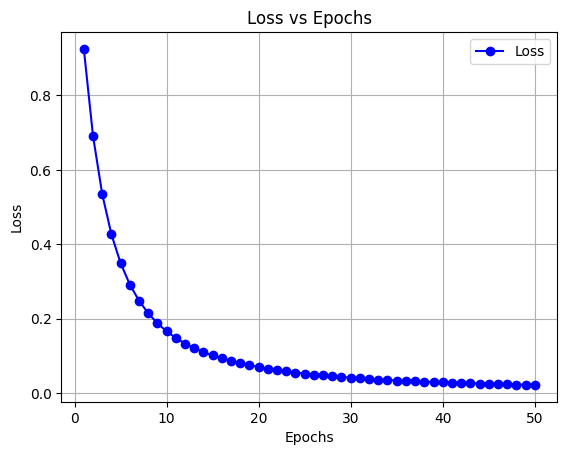

In [29]:
import matplotlib.pyplot as plt

# Plot loss over epochs
plt.plot(range(1, len(losses)+1), losses, marker='o', color='blue', label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.grid(True)
plt.legend()
plt.show()
